<a href="https://colab.research.google.com/github/manav1234-creator/-Iris-Flower-Classification-using-Machine-Learning/blob/main/iris_flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Iris Flower Classification using Machine Learning

This notebook performs:
- Dataset loading and exploration
- Data cleaning checks
- Visualization and EDA
- Train/test split
- Feature scaling
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Accuracy, Precision, Recall and F1 Score
- Confusion matrices
- Model comparison
- New flower prediction
- Processed dataset export


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load Iris dataset
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully!
Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
# Basic exploration
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSpecies Distribution:")
print(df["species"].value_counts())


Dataset Shape: (150, 6)

Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target', 'species']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Duplicate Rows: 1

Species Distribution:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


In [4]:
# Remove duplicate rows if any
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (149, 6)


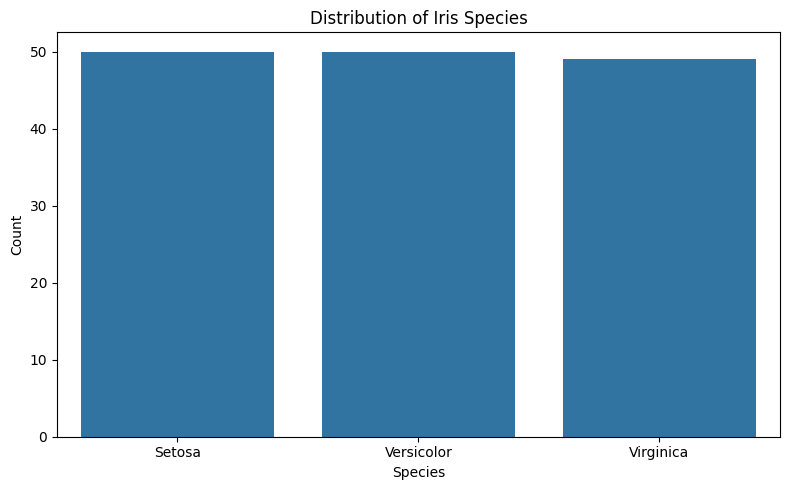

In [5]:
# Species distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="species")
plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


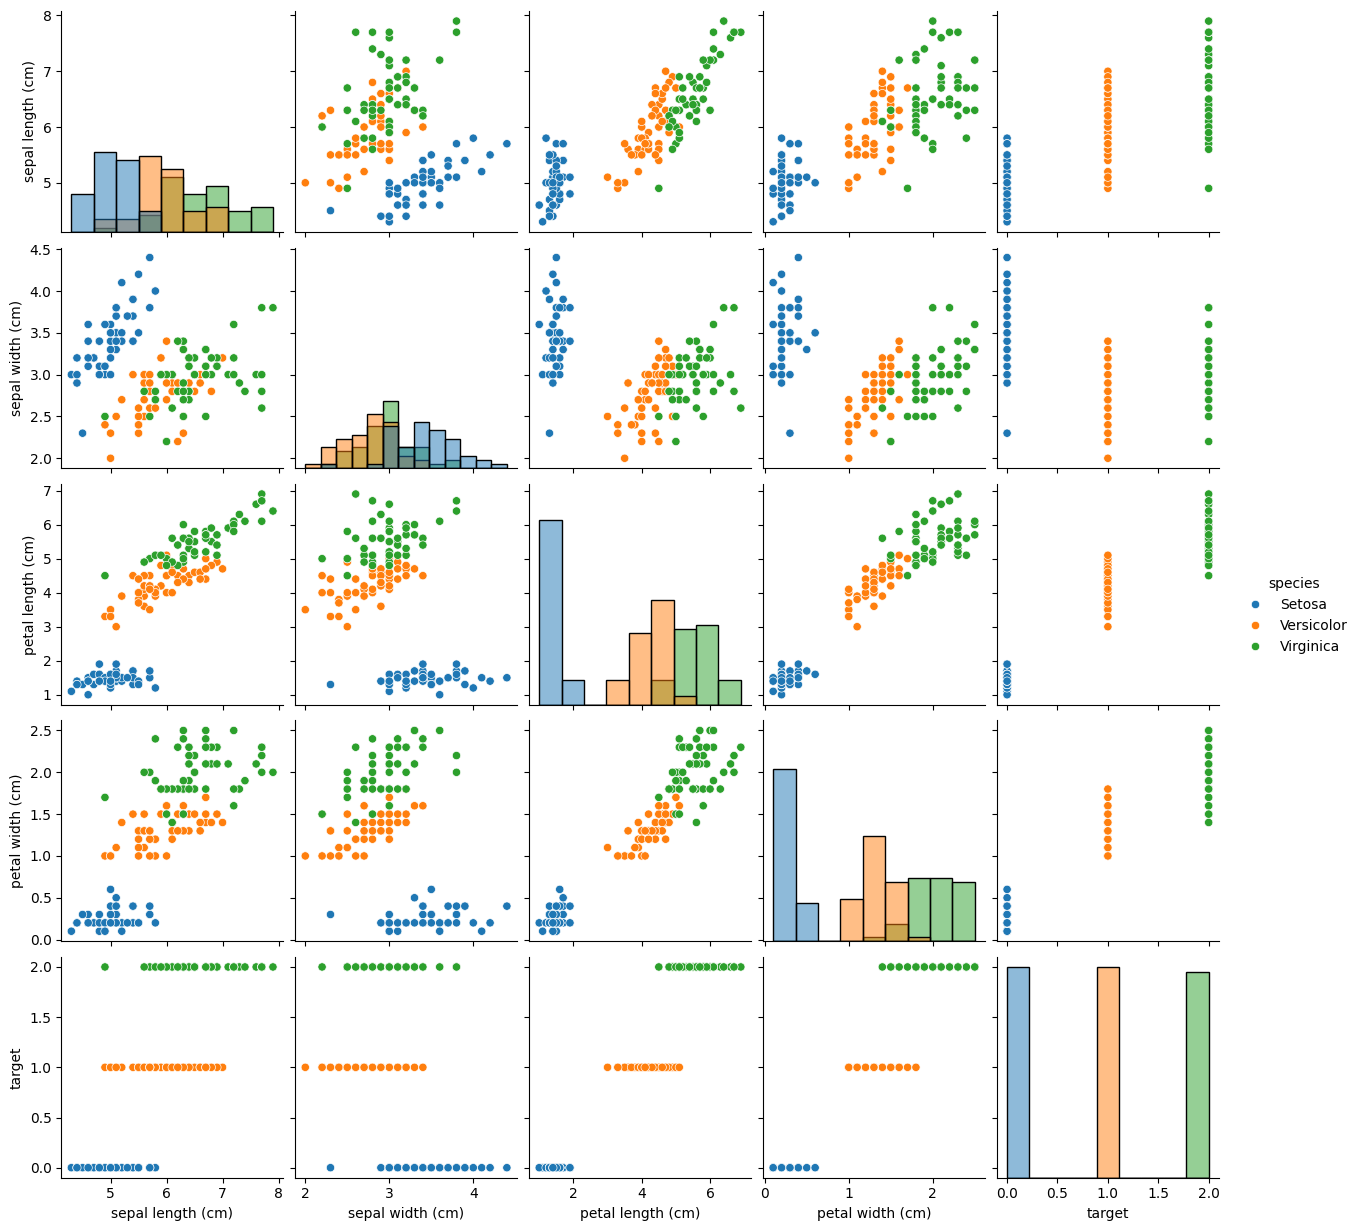

In [6]:
# Pairplot
sns.pairplot(df, hue="species", diag_kind="hist")
plt.show()


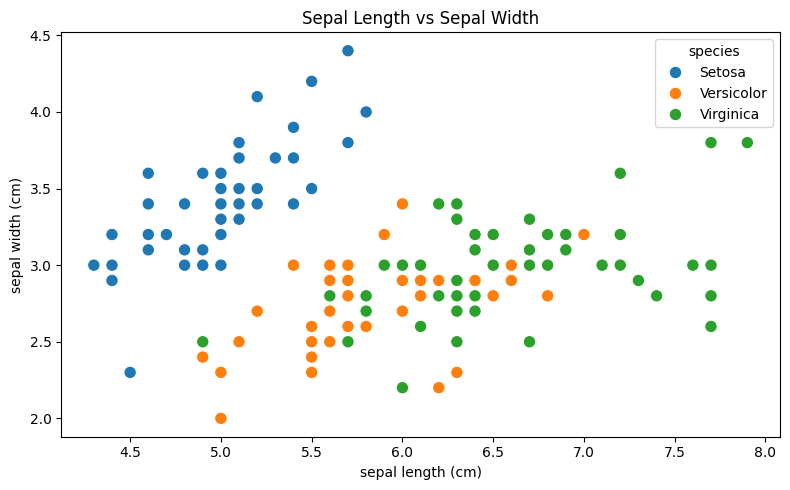

In [7]:
# Sepal scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    s=80
)
plt.title("Sepal Length vs Sepal Width")
plt.tight_layout()
plt.show()


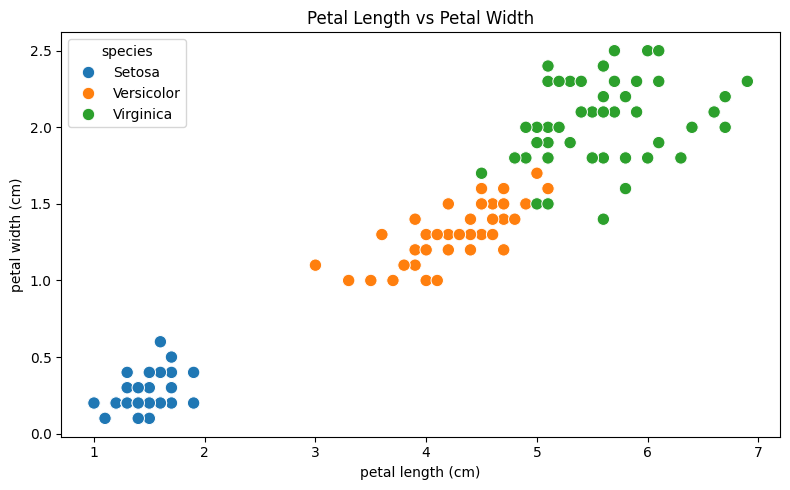

In [8]:
# Petal scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=80
)
plt.title("Petal Length vs Petal Width")
plt.tight_layout()
plt.show()


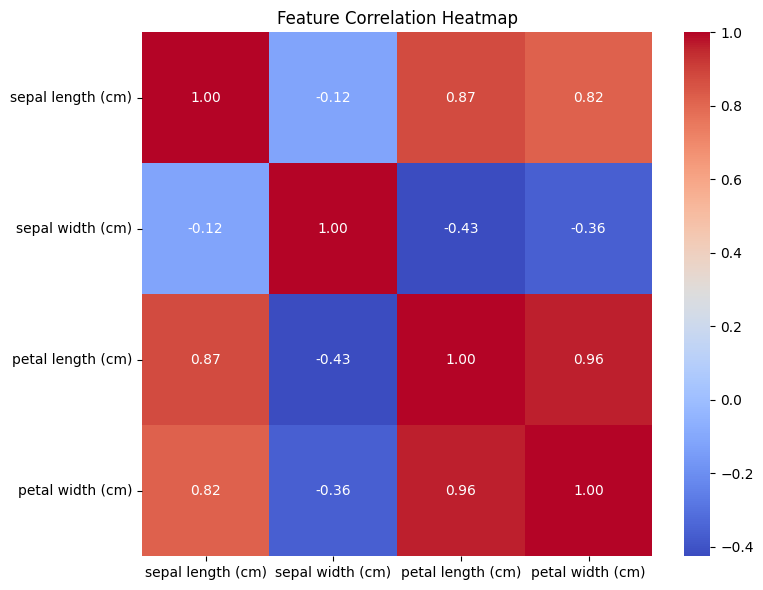

In [9]:
# Correlation heatmap
plt.figure(figsize=(8,6))
correlation = df.iloc[:, :4].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


In [10]:
# Define features and target
X = df.iloc[:, :4]
y = df["target"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())


Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


,target
0,0
1,0
2,0
3,0
4,0


In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 119
Testing samples: 30


In [12]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")


Feature scaling completed!


## 🤖 Model 1 — Logistic Regression


In [13]:
# Train Logistic Regression
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic, average="weighted")
recall_logistic = recall_score(y_test, y_pred_logistic, average="weighted")
f1_logistic = f1_score(y_test, y_pred_logistic, average="weighted")

print("LOGISTIC REGRESSION")
print("-" * 35)
print("Accuracy :", round(accuracy_logistic, 4))
print("Precision:", round(precision_logistic, 4))
print("Recall   :", round(recall_logistic, 4))
print("F1 Score :", round(f1_logistic, 4))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_logistic,
    target_names=iris.target_names
))


LOGISTIC REGRESSION
-----------------------------------
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 🤖 Model 2 — K-Nearest Neighbors


In [14]:
# Train KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average="weighted")
recall_knn = recall_score(y_test, y_pred_knn, average="weighted")
f1_knn = f1_score(y_test, y_pred_knn, average="weighted")

print("KNN")
print("-" * 35)
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_knn,
    target_names=iris.target_names
))


KNN
-----------------------------------
Accuracy : 0.9333
Precision: 0.9444
Recall   : 0.9333
F1 Score : 0.9327

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 🌳 Model 3 — Decision Tree


In [15]:
# Train Decision Tree
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree, average="weighted")
recall_tree = recall_score(y_test, y_pred_tree, average="weighted")
f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("DECISION TREE")
print("-" * 35)
print("Accuracy :", round(accuracy_tree, 4))
print("Precision:", round(precision_tree, 4))
print("Recall   :", round(recall_tree, 4))
print("F1 Score :", round(f1_tree, 4))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred_tree,
    target_names=iris.target_names
))


DECISION TREE
-----------------------------------
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 📊 Model Comparison


In [16]:
# Compare models
results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Accuracy": [accuracy_logistic, accuracy_knn, accuracy_tree],
    "Precision": [precision_logistic, precision_knn, precision_tree],
    "Recall": [recall_logistic, recall_knn, recall_tree],
    "F1 Score": [f1_logistic, f1_knn, f1_tree]
})

display(results.round(4))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333
1,KNN,0.9333,0.9444,0.9333,0.9327
2,Decision Tree,0.9333,0.9333,0.9333,0.9333


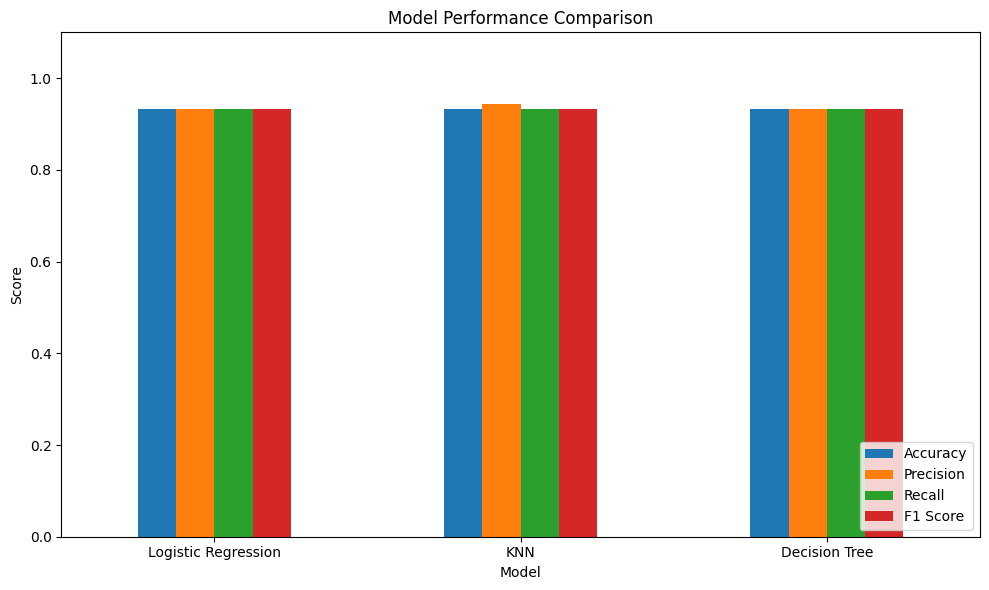

In [17]:
# Model comparison chart
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 🔲 Confusion Matrices


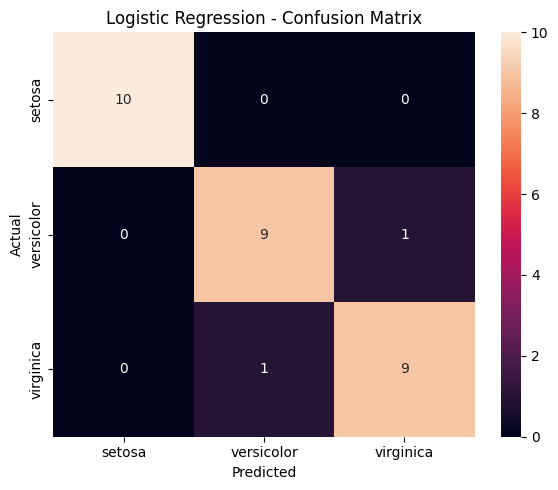

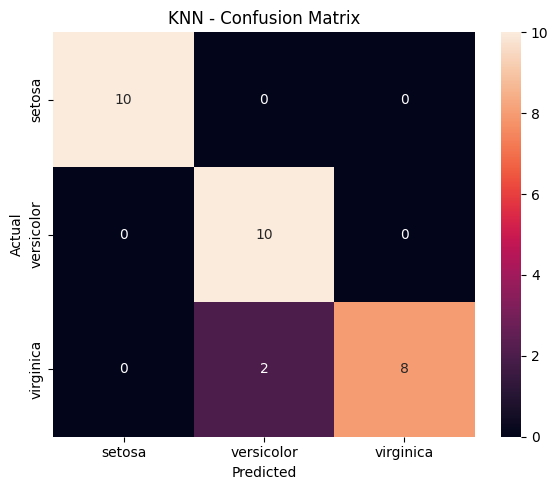

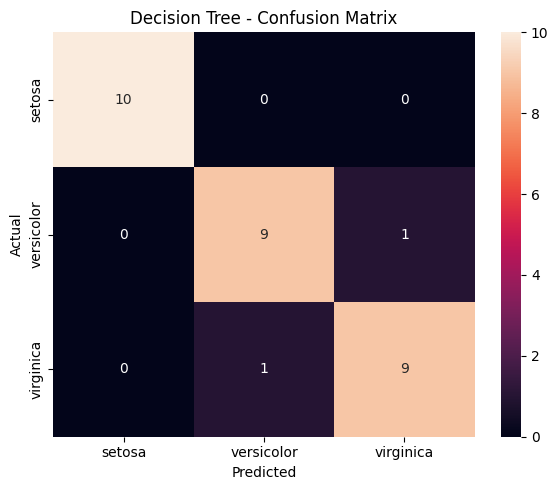

In [18]:
# Confusion matrices for all models
predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_tree
}

for model_name, predictions_model in predictions.items():
    cm = confusion_matrix(y_test, predictions_model)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


## 🌳 Decision Tree Visualization


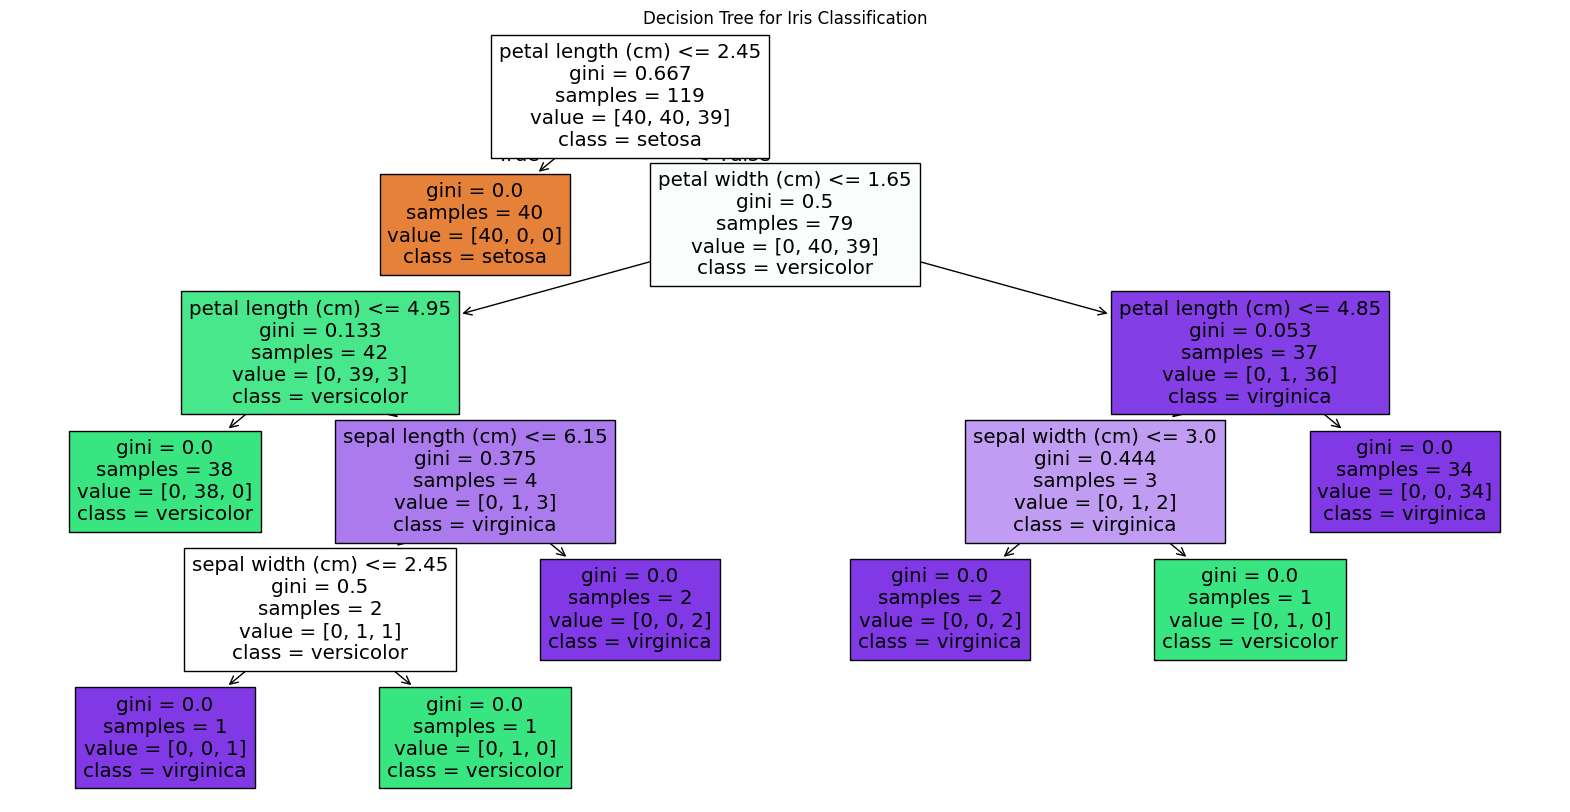

In [19]:
plt.figure(figsize=(20,10))

plot_tree(
    decision_tree_model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.title("Decision Tree for Iris Classification")
plt.show()


## 🌺 New Flower Prediction


In [20]:
# Predict a new flower
# Format: [Sepal Length, Sepal Width, Petal Length, Petal Width]

new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

new_flower_scaled = scaler.transform(new_flower)

prediction = logistic_model.predict(new_flower_scaled)

predicted_species = iris.target_names[prediction[0]]

print("New Flower Measurements:", new_flower[0])
print("Predicted Species:", predicted_species)


New Flower Measurements: [5.1 3.5 1.4 0.2]
Predicted Species: setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
# Another example prediction
new_flower_2 = np.array([[6.5, 3.0, 5.2, 2.0]])

new_flower_2_scaled = scaler.transform(new_flower_2)

prediction_2 = logistic_model.predict(new_flower_2_scaled)

predicted_species_2 = iris.target_names[prediction_2[0]]

print("New Flower Measurements:", new_flower_2[0])
print("Predicted Species:", predicted_species_2)


New Flower Measurements: [6.5 3.  5.2 2. ]
Predicted Species: virginica


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 💾 Save Processed Dataset


In [22]:
# Save processed dataset
processed_file = "processed_iris_dataset.csv"

df.to_csv(processed_file, index=False)

print("Saved:", processed_file)


Saved: processed_iris_dataset.csv


In [23]:
# Download processed dataset when running in Google Colab
try:
    from google.colab import files
    files.download("processed_iris_dataset.csv")
except ImportError:
    print("Not running in Google Colab. File has been saved locally.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🏆 Final Project Summary


In [24]:
# Final summary
best_model = results.loc[results["Accuracy"].idxmax()]

print("=" * 50)
print("       IRIS FLOWER CLASSIFICATION")
print("=" * 50)

print("Dataset samples:", len(df))
print("Features:", 4)
print("Classes:", list(iris.target_names))

print("\nModel Results:")
display(results.round(4))

print("\nBest Model:", best_model["Model"])
print("Best Accuracy:", round(best_model["Accuracy"] * 100, 2), "%")

print("\nProject completed successfully! 🎉")


       IRIS FLOWER CLASSIFICATION
Dataset samples: 149
Features: 4
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Model Results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9333,0.9333,0.9333,0.9333
1,KNN,0.9333,0.9444,0.9333,0.9327
2,Decision Tree,0.9333,0.9333,0.9333,0.9333



Best Model: Logistic Regression
Best Accuracy: 93.33 %

Project completed successfully! 🎉
